# Part 4: Tableau Dashboard - Sales Performance Analytics

**Student:** sknisreen | **ID:** 2511813

This notebook prepares `dashboard_sales_data.xlsx` for dashboard analysis, computes KPIs, builds visual insights across region, segment, category, campaign channel, returns, delivery, and ratings, and exports a Tableau-ready dataset.

> **Note:** Use **Kernel -> Restart & Run All** to run the analysis and save plots to `screenshots/`.

In [1]:
# !pip install pandas numpy matplotlib seaborn openpyxl

## 1. Setup and Data Loading

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = Path('data')
DATA_FILE = DATA_DIR / 'dashboard_sales_data.xlsx'
PREPARED_FILE = DATA_DIR / 'dashboard_sales_prepared.csv'
SCREENSHOTS_DIR = Path('screenshots')
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)


def show_plot(fig=None, filename=None):
    if fig is None:
        fig = plt.gcf()
    fig.tight_layout()
    if filename:
        save_path = SCREENSHOTS_DIR / filename
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved plot: {save_path}')
    display(fig)
    plt.close(fig)


raw_df = pd.read_excel(DATA_FILE)
print(f'Records loaded: {len(raw_df):,}')
print(f'Columns: {list(raw_df.columns)}')
print(f'Date range: {raw_df["order_date"].min().date()} to {raw_df["order_date"].max().date()}')

Records loaded: 4,200
Columns: ['order_id', 'order_date', 'ship_date', 'customer_id', 'customer_segment', 'region', 'state', 'city', 'category', 'sub_category', 'product_name', 'ship_mode', 'sales', 'quantity', 'discount', 'profit', 'return_flag', 'delivery_days', 'customer_rating', 'campaign_channel']
Date range: 2024-01-01 to 2025-12-31


## 2. Data Preparation for Dashboard

Create derived fields used in Tableau KPIs and charts; handle missing values.

In [3]:
df = raw_df.copy()

# Derived dashboard fields
df['profit_margin'] = np.where(df['sales'] != 0, df['profit'] / df['sales'], np.nan)
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.to_period('M').astype(str)
df['order_quarter'] = df['order_date'].dt.to_period('Q').astype(str)

# Impute missing values for dashboard dimensions
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())
df['campaign_channel'] = df['campaign_channel'].fillna('Unknown')

print('Missing values after preparation:')
display(df.isnull().sum().to_frame('missing_count').T)

print('\nDerived fields sample:')
display(df[['order_id', 'sales', 'profit', 'profit_margin', 'return_flag', 'delivery_days', 'customer_rating', 'campaign_channel', 'order_month']].head())

Missing values after preparation:


,order_id,order_date,ship_date,customer_id,customer_segment,region,state,city,category,sub_category,...,discount,profit,return_flag,delivery_days,customer_rating,campaign_channel,profit_margin,order_year,order_month,order_quarter
missing_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Derived fields sample:


,order_id,sales,profit,profit_margin,return_flag,delivery_days,customer_rating,campaign_channel,order_month
0,DB-2024-500001,46431.81,4220.45,0.090896,0,1,4.4,Organic,2024-01
1,DB-2024-500002,1571.91,373.32,0.237495,0,5,3.8,Social,2024-08
2,DB-2025-500003,24369.68,-1582.84,-0.064951,0,1,5.0,Referral,2025-07
3,DB-2025-500004,271439.86,65335.24,0.240699,0,3,4.0,Organic,2025-04
4,DB-2025-500005,102228.61,10735.15,0.105011,0,4,4.0,Social,2025-02


## 3. Exploratory Data Analysis (EDA)

In [4]:
print('--- Numeric summary ---')
display(df.describe().T)

print('\n--- Categorical distributions ---')
for col in ['customer_segment', 'region', 'category', 'ship_mode', 'campaign_channel', 'return_flag']:
    print(f'\n{col}:')
    display(df[col].value_counts().head(10).to_frame('count'))

--- Numeric summary ---


,count,mean,min,25%,50%,75%,max,std
order_date,4200,2025-01-05 06:17:29.142857216,2024-01-01 00:00:00,2024-07-12 18:00:00,2025-01-08 00:00:00,2025-07-10 00:00:00,2025-12-31 00:00:00,NaN
ship_date,4200,2025-01-08 20:31:12,2024-01-03 00:00:00,2024-07-16 00:00:00,2025-01-12 00:00:00,2025-07-13 00:00:00,2026-01-06 00:00:00,NaN
sales,4200.0,51670.869505,72.91,6340.395,19288.255,69150.4875,427418.19,71258.78315
quantity,4200.0,5.502857,1.0,3.0,5.0,8.0,10.0,2.886846
discount,4200.0,0.137333,0.0,0.05,0.15,0.25,0.35,0.10908
profit,4200.0,7930.074486,-17757.55,475.0275,1854.16,8513.3875,133628.04,14744.487
return_flag,4200.0,0.045476,0.0,0.0,0.0,0.0,1.0,0.208371
delivery_days,4200.0,3.592857,0.0,2.0,4.0,5.0,9.0,1.899711
customer_rating,4200.0,4.063357,2.1,3.7,4.1,4.4,5.0,0.537711
profit_margin,4200.0,0.131235,-0.199932,0.085679,0.137711,0.187676,0.356584,0.082704



--- Categorical distributions ---

customer_segment:


,count
customer_segment,
Home Office,1446
Corporate,1399
Consumer,1355



region:


...

,count
ship_mode,
Standard Class,2435
Second Class,894
First Class,630
Same Day,241



campaign_channel:


,count
campaign_channel,
Organic,1694
Paid,849
Email,657
Social,584
Referral,392
Unknown,24



return_flag:


,count
return_flag,
0,4009
1,191


Saved plot: screenshots/eda_sales_profit_discount_returns.png


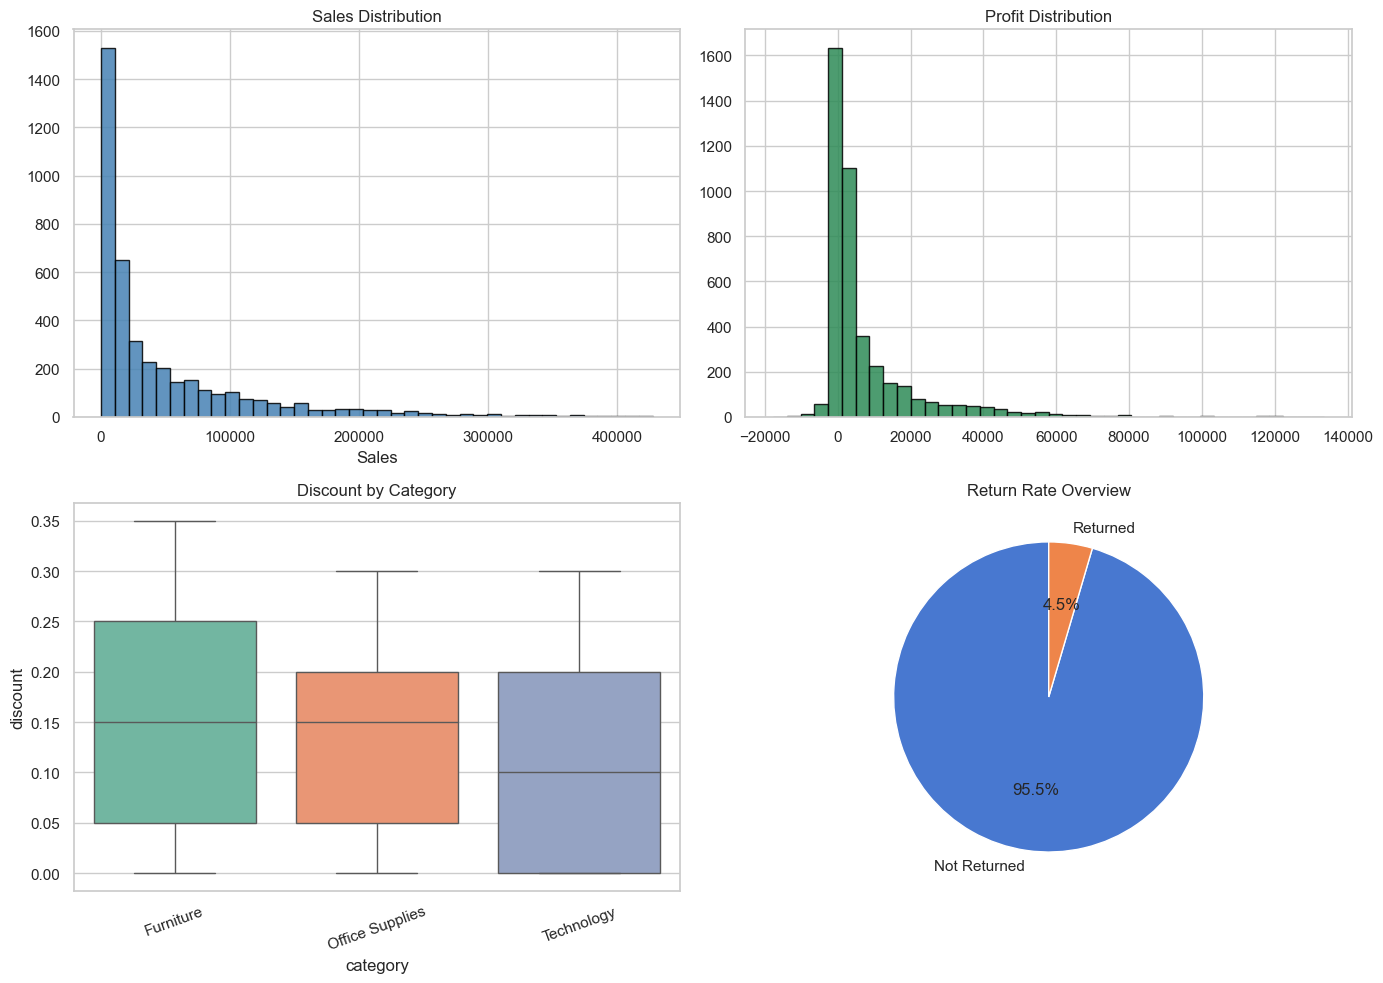

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['sales'], bins=40, color='steelblue', edgecolor='black', alpha=0.85)
axes[0, 0].set_title('Sales Distribution')
axes[0, 0].set_xlabel('Sales')

axes[0, 1].hist(df['profit'], bins=40, color='seagreen', edgecolor='black', alpha=0.85)
axes[0, 1].set_title('Profit Distribution')

sns.boxplot(data=df, x='category', y='discount', hue='category', ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('Discount by Category')
axes[1, 0].tick_params(axis='x', rotation=20)

df['return_flag'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', labels=['Not Returned', 'Returned'], startangle=90)
axes[1, 1].set_title('Return Rate Overview')
axes[1, 1].set_ylabel('')
show_plot(fig, 'eda_sales_profit_discount_returns.png')

## 4. Executive KPI Summary

Core dashboard KPIs for leadership monitoring.

--- Executive KPIs ---


,value
Total Sales,2.170177e+08
Total Profit,3.330631e+07
Overall Profit Margin,1.535000e-01
Total Orders,4.200000e+03
Return Rate,4.550000e-02
Avg Delivery Days,3.592900e+00
Avg Customer Rating,4.063400e+00
Avg Discount,1.373000e-01


Saved plot: screenshots/dashboard_executive_kpi_summary.png


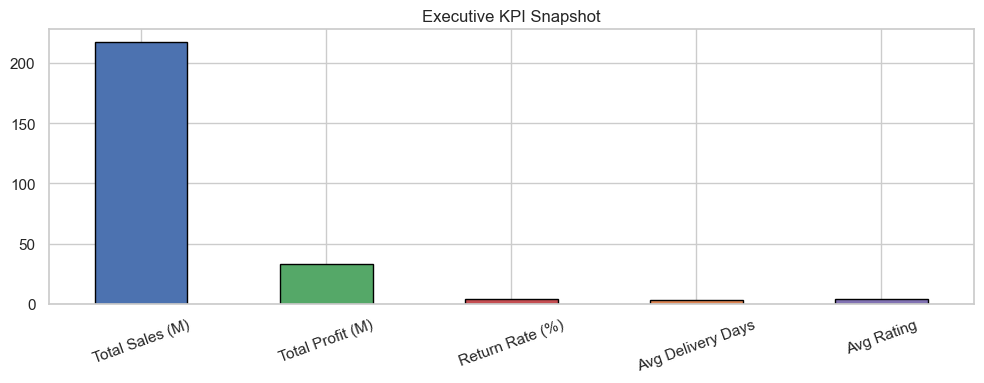

In [6]:
kpis = pd.Series({
    'Total Sales': df['sales'].sum(),
    'Total Profit': df['profit'].sum(),
    'Overall Profit Margin': df['profit'].sum() / df['sales'].sum(),
    'Total Orders': len(df),
    'Return Rate': df['return_flag'].mean(),
    'Avg Delivery Days': df['delivery_days'].mean(),
    'Avg Customer Rating': df['customer_rating'].mean(),
    'Avg Discount': df['discount'].mean(),
})
print('--- Executive KPIs ---')
display(kpis.to_frame('value').round(4))

fig, ax = plt.subplots(figsize=(10, 4))
kpi_plot = pd.Series({
    'Total Sales (M)': kpis['Total Sales'] / 1e6,
    'Total Profit (M)': kpis['Total Profit'] / 1e6,
    'Return Rate (%)': kpis['Return Rate'] * 100,
    'Avg Delivery Days': kpis['Avg Delivery Days'],
    'Avg Rating': kpis['Avg Customer Rating'],
})
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452', '#8172B2']
kpi_plot.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Executive KPI Snapshot')
ax.tick_params(axis='x', rotation=20)
show_plot(fig, 'dashboard_executive_kpi_summary.png')

## 5. Regional and Segment Performance

--- Performance by Region ---


,sales,profit,orders,return_rate,avg_rating,profit_margin
region,,,,,,
East,48859164.42,7599443.13,897,0.05,4.04,0.1555
North,54555800.53,8314884.01,1056,0.04,4.07,0.1524
South,64693706.73,9987912.33,1210,0.05,4.06,0.1544
West,48908980.24,7404073.37,1037,0.04,4.08,0.1514


Saved plot: screenshots/dashboard_sales_profit_by_region.png


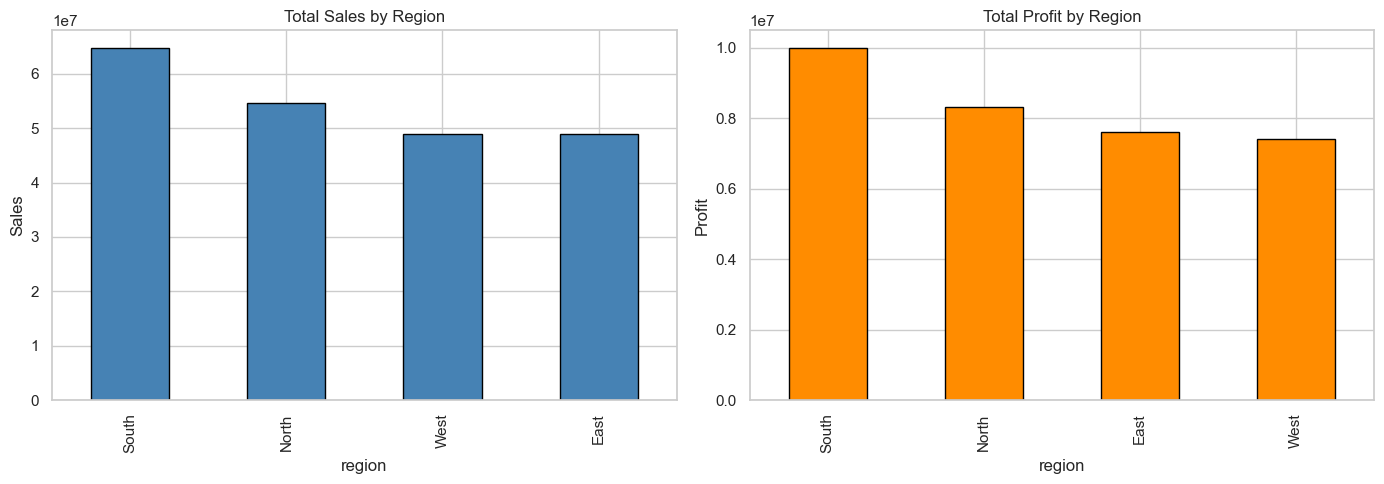


--- Performance by Customer Segment ---


,sales,profit,return_rate
customer_segment,,,
Consumer,71886173.19,11030581.12,0.04
Corporate,70630732.72,10720684.64,0.04
Home Office,74500746.01,11555047.08,0.06


Saved plot: screenshots/dashboard_segment_performance.png


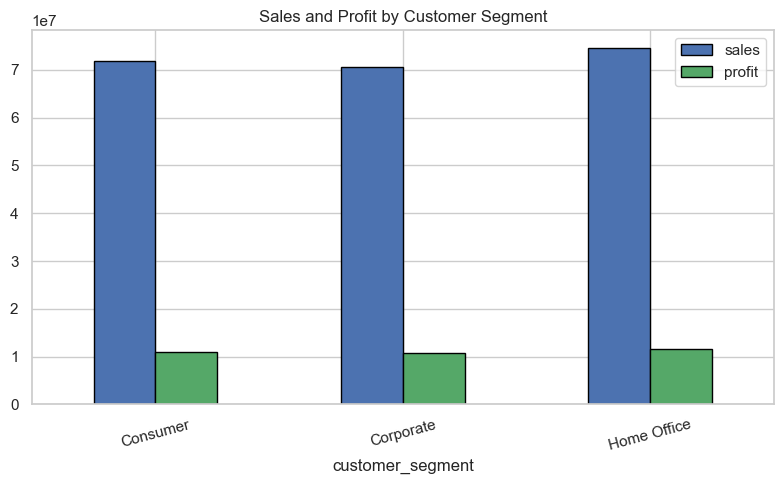

In [7]:
region_perf = df.groupby('region').agg(
    sales=('sales', 'sum'), profit=('profit', 'sum'), orders=('order_id', 'count'),
    return_rate=('return_flag', 'mean'), avg_rating=('customer_rating', 'mean'),
).round(2)
region_perf['profit_margin'] = (region_perf['profit'] / region_perf['sales']).round(4)
print('--- Performance by Region ---')
display(region_perf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_perf['sales'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Sales by Region')
axes[0].set_ylabel('Sales')
region_perf['profit'].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Total Profit by Region')
axes[1].set_ylabel('Profit')
show_plot(fig, 'dashboard_sales_profit_by_region.png')

segment_perf = df.groupby('customer_segment').agg(
    sales=('sales', 'sum'), profit=('profit', 'sum'), return_rate=('return_flag', 'mean'),
).round(2)
print('\n--- Performance by Customer Segment ---')
display(segment_perf)

fig, ax = plt.subplots(figsize=(8, 5))
segment_perf[['sales', 'profit']].plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868'], edgecolor='black')
ax.set_title('Sales and Profit by Customer Segment')
ax.tick_params(axis='x', rotation=15)
show_plot(fig, 'dashboard_segment_performance.png')

## 6. Product Category and Sub-Category Analysis

--- Category Performance ---


,sales,profit,return_rate
category,,,
Technology,1.538953e+08,28043309.91,0.03
Furniture,5.164102e+07,3557835.43,0.08
Office Supplies,1.148137e+07,1705167.50,0.04


Saved plot: screenshots/dashboard_category_sales_and_returns.png


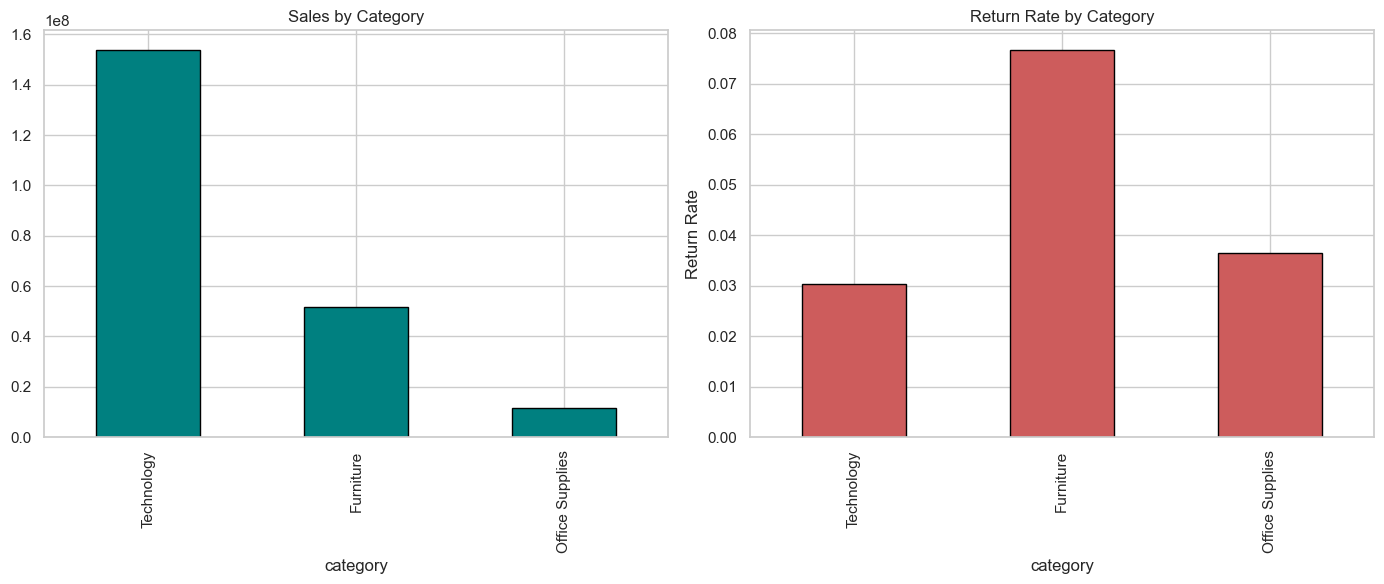

Saved plot: screenshots/dashboard_top_subcategories_sales.png


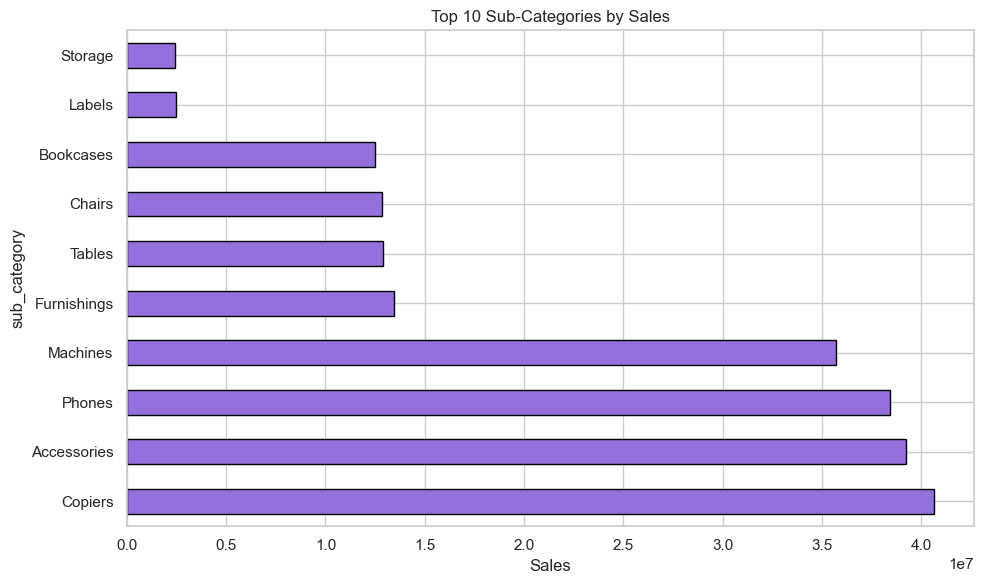

In [8]:
cat_perf = df.groupby('category').agg(
    sales=('sales', 'sum'), profit=('profit', 'sum'), return_rate=('return_flag', 'mean'),
).sort_values('sales', ascending=False)
print('--- Category Performance ---')
display(cat_perf.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cat_perf['sales'].plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Sales by Category')
cat_perf['return_rate'].plot(kind='bar', ax=axes[1], color='indianred', edgecolor='black')
axes[1].set_title('Return Rate by Category')
axes[1].set_ylabel('Return Rate')
show_plot(fig, 'dashboard_category_sales_and_returns.png')

top_sub = df.groupby('sub_category')['sales'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
top_sub.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Top 10 Sub-Categories by Sales')
ax.set_xlabel('Sales')
show_plot(fig, 'dashboard_top_subcategories_sales.png')

## 7. Campaign Channel and Shipping Analysis

--- Campaign Channel Performance ---


,sales,profit,orders,return_rate,avg_rating
campaign_channel,,,,,
Organic,88783980.90,13444456.85,1694,0.04,4.05
Paid,40111108.72,6053063.73,849,0.05,4.09
Email,34512356.53,5364557.51,657,0.05,4.06
Social,31104556.50,4911552.90,584,0.04,4.07
Referral,21211566.38,3336084.38,392,0.06,4.07
Unknown,1294082.89,196597.47,24,0.04,4.04


Saved plot: screenshots/dashboard_campaign_channel_performance.png


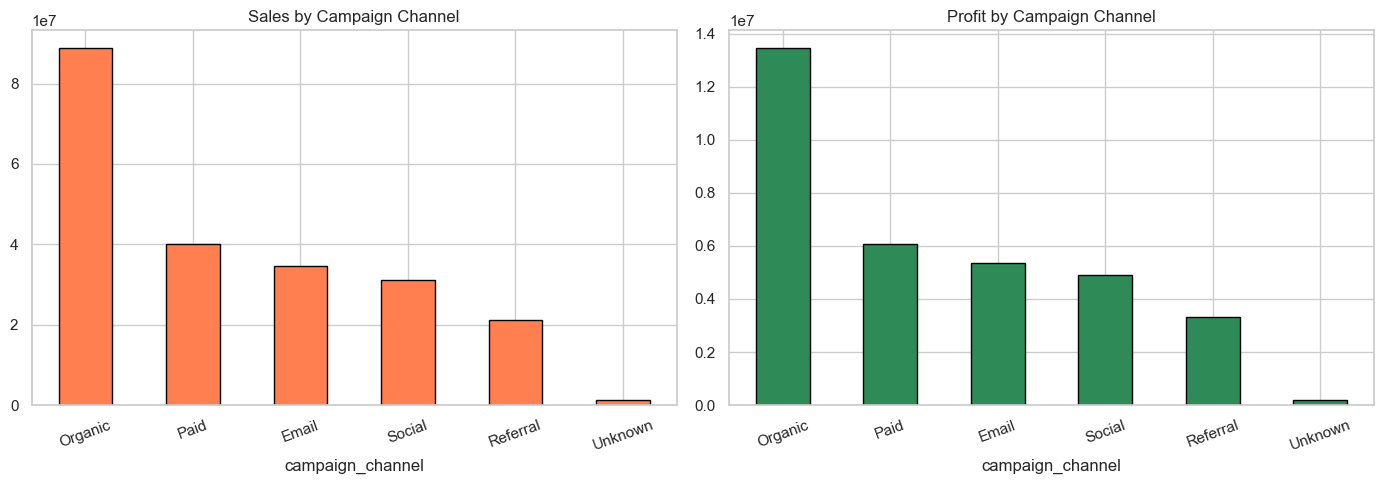


--- Ship Mode Performance ---


,orders,avg_delivery,return_rate
ship_mode,,,
Same Day,241,0.40,0.02
First Class,630,1.77,0.05
Second Class,894,2.68,0.05
Standard Class,2435,4.71,0.05


Saved plot: screenshots/dashboard_delivery_by_ship_mode.png


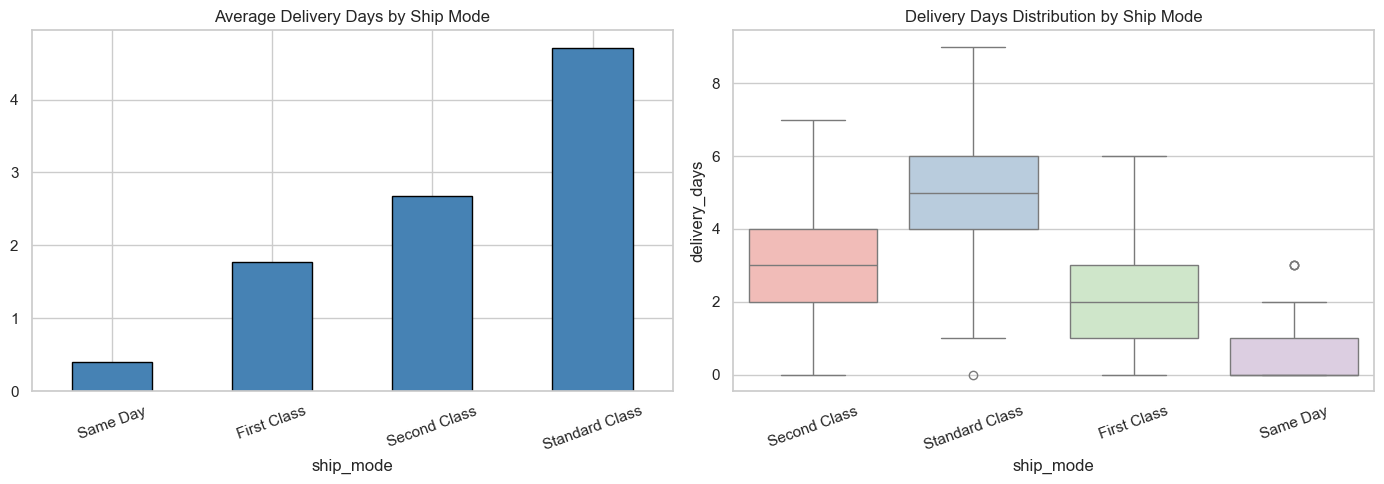

In [9]:
channel_perf = df.groupby('campaign_channel').agg(
    sales=('sales', 'sum'), profit=('profit', 'sum'), orders=('order_id', 'count'),
    return_rate=('return_flag', 'mean'), avg_rating=('customer_rating', 'mean'),
).sort_values('sales', ascending=False)
print('--- Campaign Channel Performance ---')
display(channel_perf.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
channel_perf['sales'].plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Sales by Campaign Channel')
axes[0].tick_params(axis='x', rotation=20)
channel_perf['profit'].plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Profit by Campaign Channel')
axes[1].tick_params(axis='x', rotation=20)
show_plot(fig, 'dashboard_campaign_channel_performance.png')

ship_perf = df.groupby('ship_mode').agg(
    orders=('order_id', 'count'), avg_delivery=('delivery_days', 'mean'), return_rate=('return_flag', 'mean'),
).sort_values('avg_delivery')
print('\n--- Ship Mode Performance ---')
display(ship_perf.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ship_perf['avg_delivery'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Average Delivery Days by Ship Mode')
axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='ship_mode', y='delivery_days', hue='ship_mode', ax=axes[1], palette='Pastel1', legend=False)
axes[1].set_title('Delivery Days Distribution by Ship Mode')
axes[1].tick_params(axis='x', rotation=20)
show_plot(fig, 'dashboard_delivery_by_ship_mode.png')

## 8. Time Trends and Return Analysis

--- Monthly Trend (last 6 months) ---


,sales,profit,orders,return_rate
order_month,,,,
2025-07,10661968.18,1831220.41,189,0.04
2025-08,10861499.92,1735384.80,203,0.08
2025-09,8033155.97,1184389.44,165,0.07
2025-10,10109298.77,1519629.18,198,0.07
2025-11,10203938.54,1608714.65,195,0.03
2025-12,9095351.76,1397756.65,159,0.06


Saved plot: screenshots/dashboard_monthly_sales_profit_return_trend.png


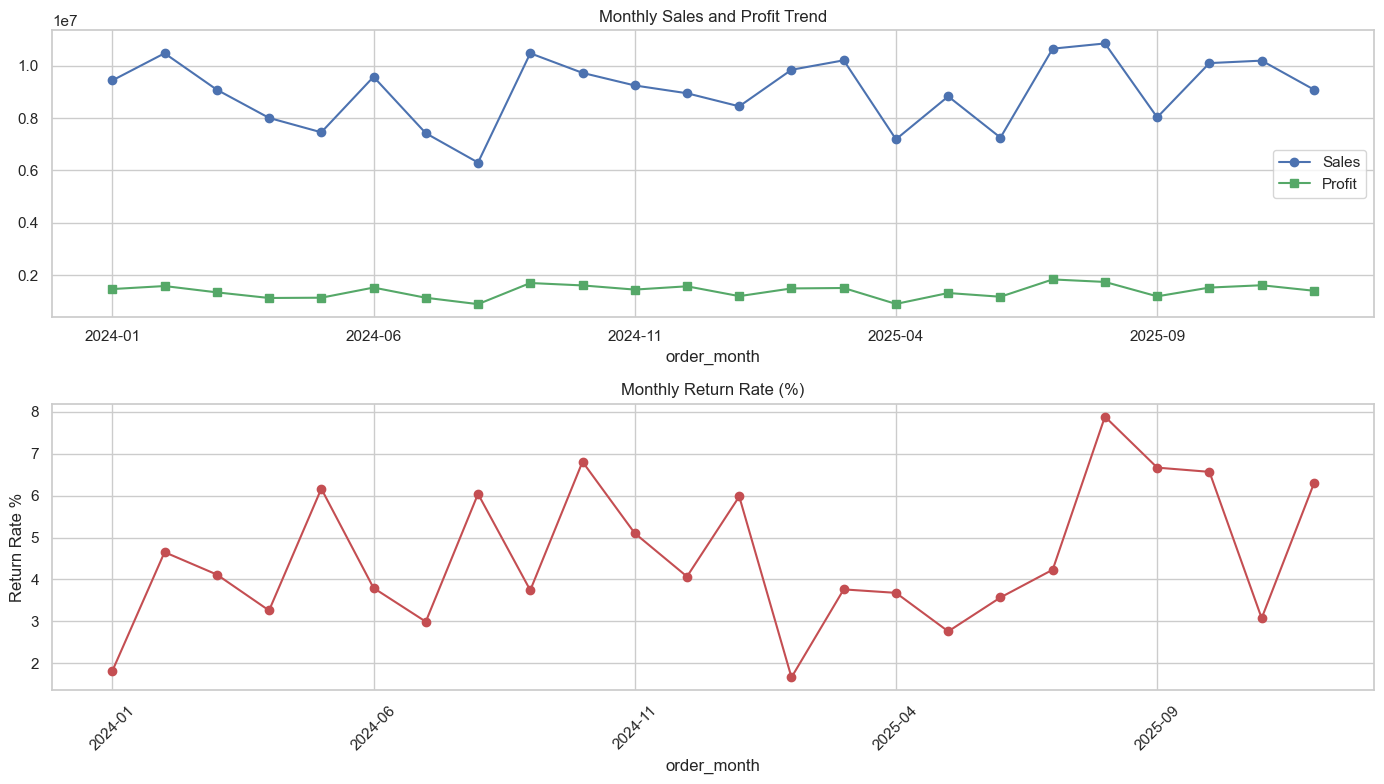

Saved plot: screenshots/dashboard_return_rate_by_region.png


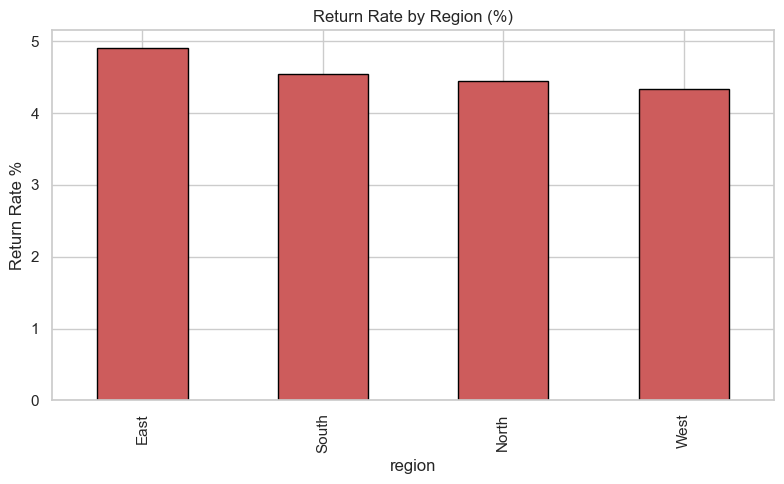

In [10]:
monthly = df.groupby('order_month').agg(
    sales=('sales', 'sum'), profit=('profit', 'sum'), orders=('order_id', 'count'),
    return_rate=('return_flag', 'mean'),
).sort_index()
print('--- Monthly Trend (last 6 months) ---')
display(monthly.tail(6).round(2))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
monthly['sales'].plot(kind='line', marker='o', ax=axes[0], color='#4C72B0', label='Sales')
monthly['profit'].plot(kind='line', marker='s', ax=axes[0], color='#55A868', label='Profit')
axes[0].set_title('Monthly Sales and Profit Trend')
axes[0].legend()
(monthly['return_rate'] * 100).plot(kind='line', marker='o', ax=axes[1], color='#C44E52')
axes[1].set_title('Monthly Return Rate (%)')
axes[1].set_ylabel('Return Rate %')
axes[1].tick_params(axis='x', rotation=45)
show_plot(fig, 'dashboard_monthly_sales_profit_return_trend.png')

return_by_region = df.groupby('region')['return_flag'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
(return_by_region * 100).plot(kind='bar', ax=ax, color='indianred', edgecolor='black')
ax.set_title('Return Rate by Region (%)')
ax.set_ylabel('Return Rate %')
show_plot(fig, 'dashboard_return_rate_by_region.png')

## 9. Customer Rating and Profit Margin Heatmap

Saved plot: screenshots/dashboard_customer_rating_by_channel.png


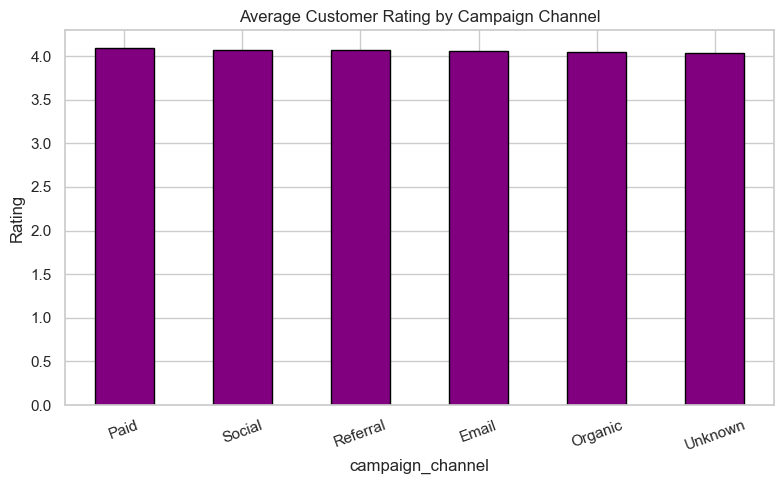

Saved plot: screenshots/dashboard_profit_margin_heatmap.png


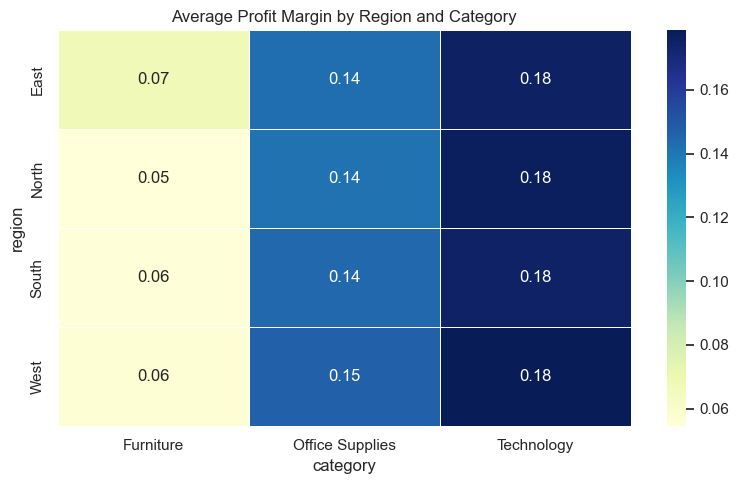

Saved plot: screenshots/dashboard_top_states_sales.png


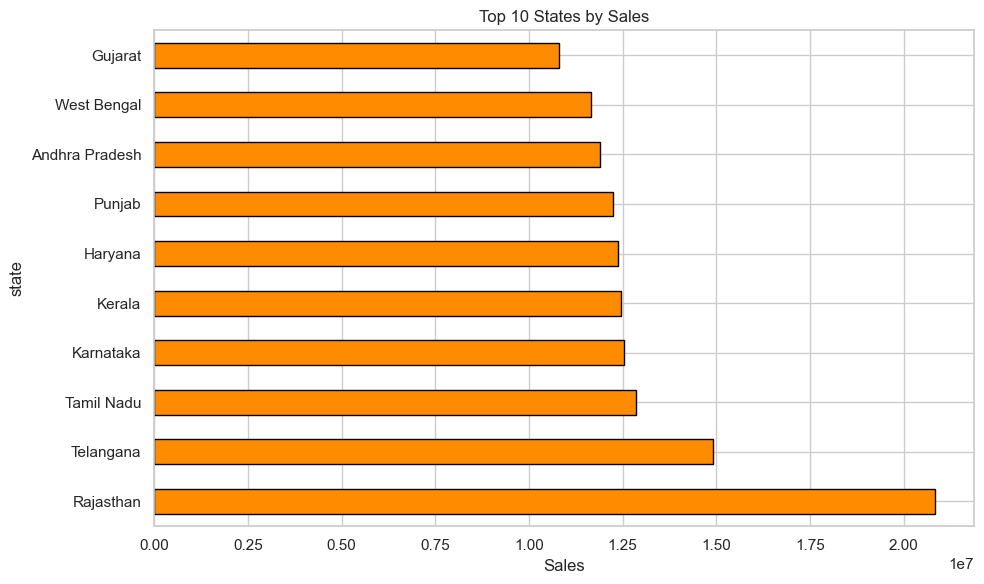

In [11]:
rating_by_channel = df.groupby('campaign_channel')['customer_rating'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
rating_by_channel.plot(kind='bar', ax=ax, color='purple', edgecolor='black')
ax.set_title('Average Customer Rating by Campaign Channel')
ax.set_ylabel('Rating')
ax.tick_params(axis='x', rotation=20)
show_plot(fig, 'dashboard_customer_rating_by_channel.png')

margin_pivot = df.pivot_table(index='region', columns='category', values='profit_margin', aggfunc='mean')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(margin_pivot, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Average Profit Margin by Region and Category')
show_plot(fig, 'dashboard_profit_margin_heatmap.png')

top_states = df.groupby('state')['sales'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
top_states.plot(kind='barh', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Top 10 States by Sales')
ax.set_xlabel('Sales')
show_plot(fig, 'dashboard_top_states_sales.png')

## 10. Export Prepared Data for Tableau

Export cleaned dataset with derived fields for Tableau Desktop connection.

In [12]:
df.to_csv(PREPARED_FILE, index=False)
print(f'Exported Tableau-ready file: {PREPARED_FILE}')
print(f'Rows: {len(df):,} | Columns: {len(df.columns)}')

Exported Tableau-ready file: data/dashboard_sales_prepared.csv
Rows: 4,200 | Columns: 24


## 11. Dashboard Design Summary

Recommended Tableau dashboard layout:

| Section | Charts / KPIs |
|---------|----------------|
| **KPI row** | Total sales, profit, margin, return rate, avg delivery days, avg rating |
| **Geography** | Sales/profit by region and top states map or bar chart |
| **Products** | Category and sub-category performance, return rate by category |
| **Customers** | Segment comparison, rating by channel |
| **Operations** | Delivery days by ship mode, monthly trends |
| **Filters** | Region, segment, category, campaign channel, date range |

**Key insight:** Technology drives the majority of sales and profit; Furniture has the highest return rate and should be monitored closely in the dashboard.